In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm 
from week3.seoul_client import get_subway_data, SubwaySchema, get_bike_data, BikeSchema
from week3.nation_trade_client import get_nation_trade_data, NationTradeSchema

# 1. 폰트 파일 경로 지정
font_path = '../week1/content/NanumBarunGothic.ttf'
# 2. 폰트 이름 가져오기
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
# 3. 모든 폰트 설정 업데이트
plt.rc('font', family=font_name)
# 마이너스 기호 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = font_name


subway = SubwaySchema.validate_df(get_subway_data(use_ymd='20260403', end_index=1000))

subway.info

subway.head()
subway.tail()

,USE_YMD,SBWY_ROUT_LN_NM,SBWY_STNS_NM,GTON_TNOPE,GTOFF_TNOPE,REG_YMD
615,20260403,신림선,당곡,5775,5469,20260406
616,20260403,신림선,신림,2622,3215,20260406
617,20260403,신림선,서원,4258,3577,20260406
618,20260403,신림선,서울대벤처타운,12308,10794,20260406
619,20260403,신림선,관악산(서울대),3788,3583,20260406


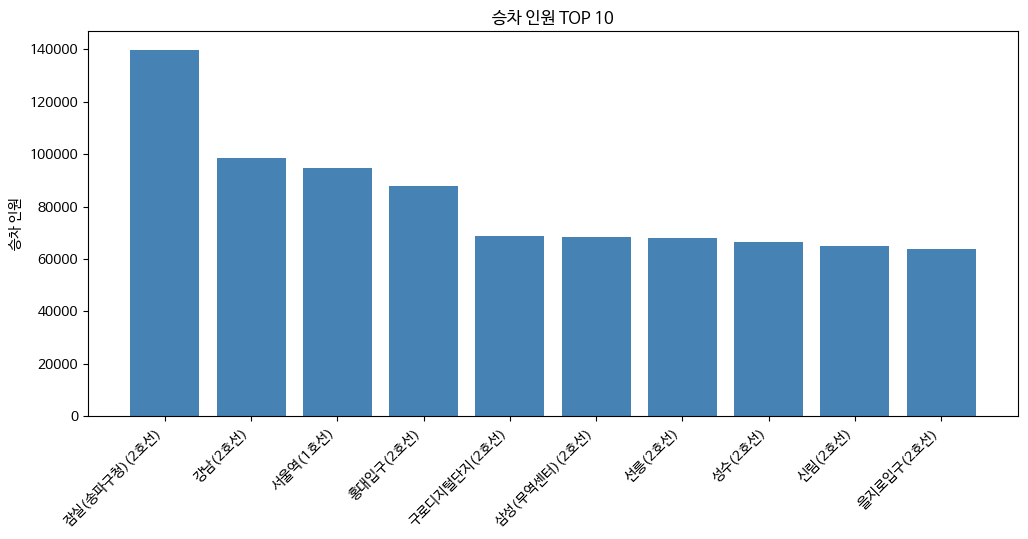

In [4]:
subway_top10 = subway.sort_values(by=SubwaySchema.GTON_TNOPE, ascending=False).head(10).reset_index(drop=True)
plt.figure(figsize=(12,5))
labels = subway_top10[SubwaySchema.SBWY_STNS_NM] + '(' + subway_top10[SubwaySchema.SBWY_ROUT_LN_NM] + ')'
plt.bar(labels, subway_top10[SubwaySchema.GTON_TNOPE], color = 'steelblue')
plt.title('승차 인원 TOP 10')
plt.ylabel('승차 인원')
plt.xticks(rotation=45, ha='right')
plt.show()

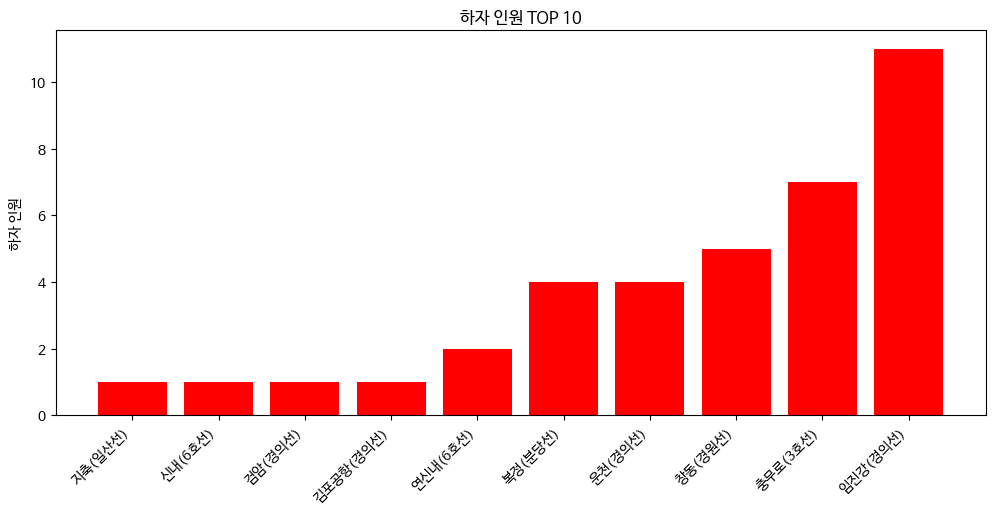

In [5]:
subway_bottom10 = subway.sort_values(by=SubwaySchema.GTON_TNOPE, ascending=True).head(10).reset_index(drop=True)
plt.figure(figsize=(12,5))
labels = subway_bottom10[SubwaySchema.SBWY_STNS_NM] + '(' + subway_bottom10[SubwaySchema.SBWY_ROUT_LN_NM] + ')'
plt.bar(labels, subway_bottom10[SubwaySchema.GTON_TNOPE], color = 'red')
plt.title('하자 인원 TOP 10')
plt.ylabel('하자 인원')
plt.xticks(rotation=45, ha='right')
plt.show()

In [6]:
im_export = NationTradeSchema.validate_df(get_nation_trade_data(strt_yymm='202501', end_yymm='202512'))

im_export.head()

,balPayments,expCnt,expDlr,impCnt,impDlr,statCd,statCdCntnKor1,year
0,3.443226e+09,193178,9.282567e+09,1416582,5.839341e+09,US,미국,2025.01
1,-2.004621e+09,91388,9.204172e+09,1225173,1.120879e+10,CN,중국,2025.01
2,1.792245e+09,57209,4.356972e+09,145132,2.564727e+09,VN,베트남,2025.01
3,2.103006e+08,34078,2.438188e+09,20022,2.227887e+09,TW,대만,2025.01
4,-1.223548e+09,146929,2.363797e+09,344783,3.587345e+09,JP,일본,2025.01


In [7]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
cols = [
    NationTradeSchema.balPayments,
    NationTradeSchema.expCnt,
    NationTradeSchema.expDlr,
    NationTradeSchema.impCnt,
    NationTradeSchema.impDlr]
im_export.info()
im_export.describe()
im_export12 = im_export.loc[im_export[NationTradeSchema.year]=='2025.12']
im_export12 = im_export12.sort_values(by=NationTradeSchema.balPayments, ascending=False)
im_export12.reset_index(drop=True, inplace=True)

im_export12.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 2830 entries, 0 to 2829
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   balPayments     2830 non-null   float64
 1   expCnt          2830 non-null   int64  
 2   expDlr          2830 non-null   float64
 3   impCnt          2830 non-null   int64  
 4   impDlr          2830 non-null   float64
 5   statCd          2830 non-null   str    
 6   statCdCntnKor1  2830 non-null   str    
 7   year            2830 non-null   str    
dtypes: float64(3), int64(2), str(3)
memory usage: 237.1 KB


,balPayments,expCnt,expDlr,impCnt,impDlr,statCd,statCdCntnKor1,year
0,5561530992.00,232653,12335136415.00,1267690,6773605423.00,US,미국,2025.12
1,4280632585.00,38739,4624113700.00,391772,343481115.00,HK,홍콩,2025.12
2,3332483885.00,67807,6281464305.00,233578,2948980420.00,VN,베트남,2025.12
3,2256773042.00,68113,5131207266.00,25051,2874434224.00,TW,대만,2025.12
4,1200481846.00,21241,1719209860.00,13877,518728014.00,IN,인도,2025.12
5,1033101128.00,54471,2069320523.00,16861,1036219395.00,SG,싱가포르,2025.12
6,1008638544.00,43,1008679079.00,12,40535.00,MH,마샬군도,2025.12
7,896992758.00,33414,1203925892.00,6328,306933134.00,PH,필리핀,2025.12
8,594935421.00,6918,744839034.00,3206,149903613.00,TR,튀르키예,2025.12
9,439455893.00,16482,1050832758.00,8690,611376865.00,MX,멕시코,2025.12


## 1.1. 서울시 공공자전거 실시간 대여정보 1,000건 가져오기

- 서울특별시 공공자전거 실시간 대여정보를 가져와 **bike** 데이터프레임을 만듭니다.
- 데이터셋은 대여소별 실시간 자전거 대여가능 건수, 거치율, 대여소 위치정보를 제공합니다.
- 호출시 시스템 부하로 한번에 최대 **1,000건**를 초과할수 없습니다.
- 우선 1,000개 행만 조회하세요.

**데이터셋 정보**

- rackTotCnt: 거치대개수
- stationName: 대여소이름
- parkingBikeTotCnt: 자전거주차총건수
- shared: 거치율
- stationLatitude: 위도
- stationLongitude: 경도
- stationId: 대여소ID

In [8]:
all_rows = []
start = 1

while True:
    # 1000건씩 호출
    rows = get_bike_data(start_index=start, end_index=start + 999)
    
    if not rows:
        break
        
    all_rows.extend(rows)
    
    # 더 이상 가져올 데이터가 없으면(1000건 미만) 종료
    if len(rows) < 1000:
        break
        
    start += 1000
    print(f"현재 {len(all_rows)}건 수집 완료...")

# 최종적으로 한 번에 검증하여 데이터프레임 생성
bike = BikeSchema.validate_df(all_rows)
bike.head()


현재 1000건 수집 완료...
현재 2000건 수집 완료...


,rackTotCnt,stationName,parkingBikeTotCnt,shared,stationLatitude,stationLongitude,stationId
0,15,102. 망원역 1번출구 앞,11,73,37.56,126.91,ST-4
1,14,103. 망원역 2번출구 앞,19,136,37.55,126.91,ST-5
2,13,104. 합정역 1번출구 앞,14,108,37.55,126.92,ST-6
3,5,105. 합정역 5번출구 앞,3,60,37.55,126.91,ST-7
4,12,106. 합정역 7번출구 앞,13,108,37.55,126.91,ST-8


### 1.3.2. 가장 많이 거치된 곳 TOP 10

- 자전거가 가장 많이 거치된 곳을 확인하기 위해 parkingBikeTotCnt 열로 내림차순 정렬한 후 상위 10개 행만 출력하세요.

In [9]:
bike.sort_values(by=BikeSchema.parkingBikeTotCnt, ascending=False).head(10).reset_index(drop=True).head(10)

,rackTotCnt,stationName,parkingBikeTotCnt,shared,stationLatitude,stationLongitude,stationId
0,62,2717.LG유플러스 마곡사옥,108,174,37.56,126.83,ST-2033
1,20,1009. 천호역4번출구(현대백화점),103,515,37.54,127.12,ST-493
2,57,5096. LG사이언스파크 E14동,96,168,37.56,126.84,ST-3251
3,15,3939.신도림역 3번출구,87,580,37.51,126.89,ST-3311
4,30,1210. 롯데월드타워(잠실역2번출구 쪽),85,283,37.51,127.10,ST-891
5,30,5515.한강버스 망원 선착장,78,260,37.55,126.90,ST-3388
6,10,4452. 삼성SDS,75,750,37.52,127.10,ST-2571
7,15,217. NH농협은행 앞,72,480,37.52,126.93,ST-66
8,20,3691. 둔촌역 2번출구,72,360,37.53,127.14,ST-2928
9,10,3925. 중앙유통단지 앞 B,72,720,37.50,126.88,ST-3124


### 1.3.3. 거치대 수가 가장 많은 곳 TOP 10

- 거치대 수가 가장 많은 곳을 확인하기 위해 rackTotCnt 열로 내림차순 정렬한 후 상위 10개 행만 출력하세요.

In [10]:
bike_top10 = bike.sort_values(by=BikeSchema.rackTotCnt, ascending=False).head(10).reset_index(drop=True)

bike_top10.head(10)

,rackTotCnt,stationName,parkingBikeTotCnt,shared,stationLatitude,stationLongitude,stationId
0,65,2728.마곡나루역 3번 출구,25,38,37.57,126.83,ST-2045
1,62,2717.LG유플러스 마곡사옥,108,174,37.56,126.83,ST-2033
2,57,5096. LG사이언스파크 E14동,96,168,37.56,126.84,ST-3251
3,51,450. 효자동 삼거리,15,29,37.58,126.97,ST-978
4,51,1193. 마곡센트럴타워 1차,30,59,37.56,126.83,ST-1688
5,46,207. 여의나루역 1번출구 앞,0,0,37.53,126.93,ST-73
6,41,2652.송파 레미니스1단지 102동 앞,0,0,37.51,127.13,ST-1873
7,40,5097. LG사이언스파크 E2동,41,103,37.56,126.83,ST-3259
8,40,5099. LG사이언스파크 E7동,41,103,37.56,126.83,ST-3260
9,40,829. 한강대교 북단 교차로,21,53,37.52,126.96,ST-1326


### 1.3.4. 지도 시각화

- 위도와 경도 정보가 있으므로 지도상에 거치대 위치를 표시할 수 있습니다.
- 지도 시각화를 위해 folium 라이브러리를 설치합니다.
- 위 분석에서 거치대가 가장 많은 곳의 좌표를 지도상에 표시합니다.

In [12]:
import folium

# 2. 지도의 중심 설정 (데이터의 평균 위도, 경도)
center = [bike_top10[BikeSchema.stationLatitude].mean(), bike_top10[BikeSchema.stationLongitude].mean()]
m = folium.Map(location=center, zoom_start=14)
# 3. 마커 추가
for _, row in bike_top10.iterrows():
    lat = row[BikeSchema.stationLatitude]
    lon = row[BikeSchema.stationLongitude]
    name = row[BikeSchema.stationName]
    bikes = row[BikeSchema.parkingBikeTotCnt]
    
    # 팝업에 정보 표시 (대여소 이름 및 자전거 대수)
    popup_text = f"{name}<br>대여 가능: {bikes}대"
    folium.Marker(
        location=[lat, lon],
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=name # 마우스 올렸을 때 표시
    ).add_to(m)
# 4. 지도 표시
m